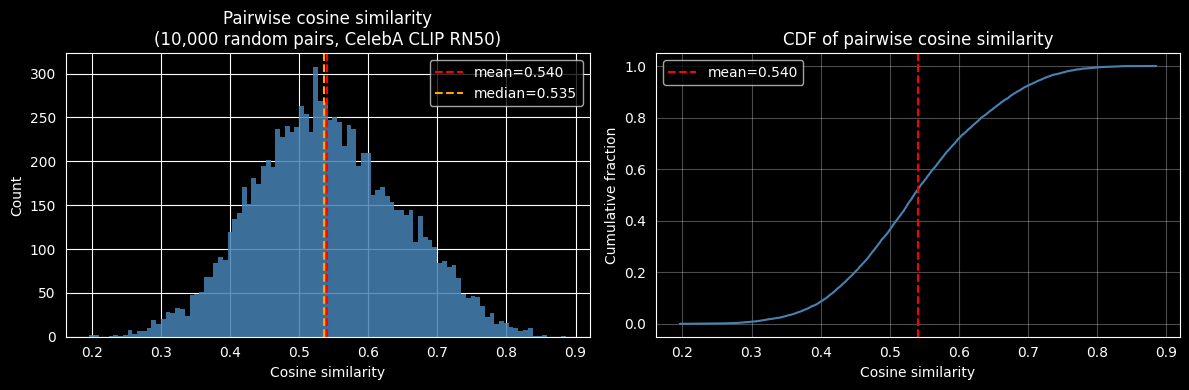

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── Load features ──────────────────────────────────────────────────────────────
features_path = "./data/activations_img/celeba/clip_RN50/out/train"
features = torch.load(features_path, map_location="cpu").float()
print(f"Loaded features: {features.shape}")  # [N, 1024]

# ── L2-normalise (required for cosine similarity = dot product) ────────────────
features = features / (features.norm(dim=-1, keepdim=True) + 1e-8)

# ── Sample random pairs ────────────────────────────────────────────────────────
N = features.shape[0]
n_pairs = 10_000  # how many random pairs to sample

idx_a = torch.randint(0, N, (n_pairs,))
idx_b = torch.randint(0, N, (n_pairs,))

# make sure we don't accidentally compare an image to itself
mask = idx_a == idx_b
idx_b[mask] = (idx_b[mask] + 1) % N

# ── Cosine similarity = dot product of unit vectors ────────────────────────────
cos_sim = (features[idx_a] * features[idx_b]).sum(dim=-1)  # [n_pairs]
cos_sim = cos_sim.numpy()

print(f"\nCosine similarity over {n_pairs:,} random pairs:")
print(f"  mean   : {cos_sim.mean():.4f}")
print(f"  median : {np.median(cos_sim):.4f}")
print(f"  std    : {cos_sim.std():.4f}")
print(f"  min    : {cos_sim.min():.4f}")
print(f"  max    : {cos_sim.max():.4f}")
print(f"  % > 0.9: {(cos_sim > 0.9).mean()*100:.1f}%")
print(f"  % > 0.8: {(cos_sim > 0.8).mean()*100:.1f}%")
print(f"  % > 0.5: {(cos_sim > 0.5).mean()*100:.1f}%")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(cos_sim, bins=100, color="steelblue", edgecolor="none", alpha=0.85)
axes[0].axvline(cos_sim.mean(),   color="red",    linestyle="--", label=f"mean={cos_sim.mean():.3f}")
axes[0].axvline(np.median(cos_sim), color="orange", linestyle="--", label=f"median={np.median(cos_sim):.3f}")
axes[0].set_xlabel("Cosine similarity")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Pairwise cosine similarity\n({n_pairs:,} random pairs, CelebA CLIP RN50)")
axes[0].legend()

# CDF
sorted_sim = np.sort(cos_sim)
cdf = np.arange(1, n_pairs + 1) / n_pairs
axes[1].plot(sorted_sim, cdf, color="steelblue")
axes[1].axvline(cos_sim.mean(), color="red",    linestyle="--", label=f"mean={cos_sim.mean():.3f}")
axes[1].set_xlabel("Cosine similarity")
axes[1].set_ylabel("Cumulative fraction")
axes[1].set_title("CDF of pairwise cosine similarity")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
import torch
import matplotlib.pyplot as plt
from sparse_autoencoder import SparseAutoencoder

# ── adjust these to match the run you want to inspect ──
sae_path = "SAE/SAEImg/celeba/clip_RN50/out/lr0.0001_l1coeff1e-05_ef4_rf500000_hookout_bs4096_epo200/sae_checkpoints/sparse_autoencoder_final.pt"
features_path = "./data/activations_img/celeba/clip_RN50/out/train"
autoencoder_input_dim = 1024
expansion_factor = 4
n_learned_features = autoencoder_input_dim * expansion_factor  # 4096

sae = SparseAutoencoder(
    n_input_features=autoencoder_input_dim,
    n_learned_features=n_learned_features,
    n_components=1,
)
sae.load_state_dict(torch.load(sae_path, map_location="cpu"))
sae.eval()
print("SAE loaded")

features = torch.load(features_path, map_location="cpu").float()
features = features / (features.norm(dim=-1, keepdim=True) + 1e-8)
print(f"Features: {features.shape}")

Features: torch.Size([146493, 1024])


In [20]:
sample = features[:5000]

with torch.no_grad():
    learned_acts, reconstructed = sae.forward(sample)

learned_acts = learned_acts.squeeze()   # [5000, n_features]
fired = (learned_acts > 0)              # boolean mask

never_fired = ~fired.any(dim=0)
print(f"Total features : {n_learned_features}")
print(f"Dead features  : {never_fired.sum().item()} ({never_fired.float().mean()*100:.1f}%)")
print(f"Mean features active per sample: {fired.float().sum(dim=1).mean():.1f}")

Total features : 4096
Dead features  : 1642 (40.1%)
Mean features active per sample: 1431.0


In [21]:
recon_error    = (sample - reconstructed.squeeze()).norm(dim=-1)
original_norm  = sample.norm(dim=-1)
relative_error = recon_error / (original_norm + 1e-8)

print(f"Reconstruction relative error:")
print(f"  mean   = {relative_error.mean():.4f}")
print(f"  median = {relative_error.median():.4f}")
print("  (good SAE: < 0.2 | poor SAE: > 0.5)")

Reconstruction relative error:
  mean   = 0.2616
  median = 0.2605
  (good SAE: < 0.2 | poor SAE: > 0.5)


In [13]:
mean_acts = learned_acts.mean(dim=0)
top_vals, top_idx = mean_acts.topk(10)

print("Top-10 most active features:")
for i, (v, idx) in enumerate(zip(top_vals, top_idx)):
    print(f"  {i+1:2d}. feature {idx:5d}  mean_act={v:.4f}  "
          f"fire_rate={fired[:, idx].float().mean()*100:.1f}%")

Top-10 most active features:
   1. feature  3545  mean_act=0.0564  fire_rate=100.0%
   2. feature  2422  mean_act=0.0468  fire_rate=99.5%
   3. feature  1793  mean_act=0.0430  fire_rate=100.0%
   4. feature  1137  mean_act=0.0415  fire_rate=99.9%
   5. feature   235  mean_act=0.0389  fire_rate=91.5%
   6. feature  2283  mean_act=0.0371  fire_rate=94.9%
   7. feature  2406  mean_act=0.0352  fire_rate=99.9%
   8. feature    77  mean_act=0.0341  fire_rate=95.7%
   9. feature  3240  mean_act=0.0340  fire_rate=97.6%
  10. feature  1545  mean_act=0.0338  fire_rate=99.9%


In [16]:
# Cell 5a — computation only
vocab_emb = torch.load("./vocab/embeddings_clip_RN50_clipdissect_20k.pth",
                       map_location="cpu").float()
vocab_emb = vocab_emb / (vocab_emb.norm(dim=-1, keepdim=True) + 1e-8)

decoder_W = sae.decoder._weight.squeeze().reshape(-1, autoencoder_input_dim)  # [n_features, 1024]
decoder_W = decoder_W / (decoder_W.norm(dim=-1, keepdim=True) + 1e-8)

sim = torch.mm(vocab_emb, decoder_W.T)   # [20000, n_features]
best_sim = sim.max(dim=0).values.detach().numpy()

print(f"mean  : {best_sim.mean():.4f}")
print(f"median: {float(torch.tensor(best_sim).median()):.4f}")
print(f"% > 0.3: {(best_sim > 0.3).mean()*100:.1f}%")
print(f"% > 0.2: {(best_sim > 0.2).mean()*100:.1f}%")

mean  : 0.0701
median: 0.0696
% > 0.3: 0.0%
% > 0.2: 0.0%


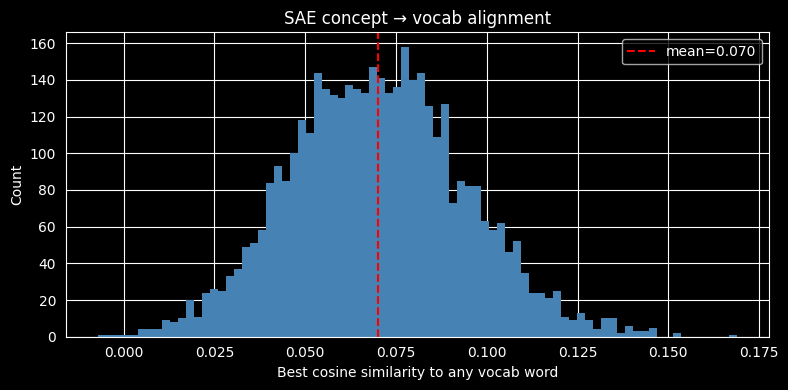

In [17]:
# Cell 5b — plot only (separate cell)
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(best_sim, bins=80, color="steelblue", edgecolor="none")
ax.axvline(best_sim.mean(), color="red", linestyle="--",
           label=f"mean={best_sim.mean():.3f}")
ax.set_xlabel("Best cosine similarity to any vocab word")
ax.set_ylabel("Count")
ax.set_title("SAE concept → vocab alignment")
ax.legend()
plt.tight_layout()
plt.show()